In [1]:

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns



In [2]:
df = pd.read_csv('/content/BlackFriday.csv')

In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


In [5]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,2.0,NaN,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,15.0,16.0,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,15.0,NaN,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,NaN,NaN,7172


In [6]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,166986


In [8]:
del df['Product_Category_2']
del df['Product_Category_3']

In [9]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,7172


Finding unique values in each column

In [10]:
df['User_ID'].nunique()

df['Product_ID'].nunique()

df['Gender'].unique()

df['Age'].unique()

df['Occupation'].unique()

df['City_Category'].unique()

df['Stay_In_Current_City_Years'].unique()

df['Marital_Status'].unique()

df['Product_Category_1'].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9])

In [ ]:
for column in df.columns:
    print(column, ":" ,df[column].nunique())

Analyzing gender

<Axes: ylabel='Ratio'>

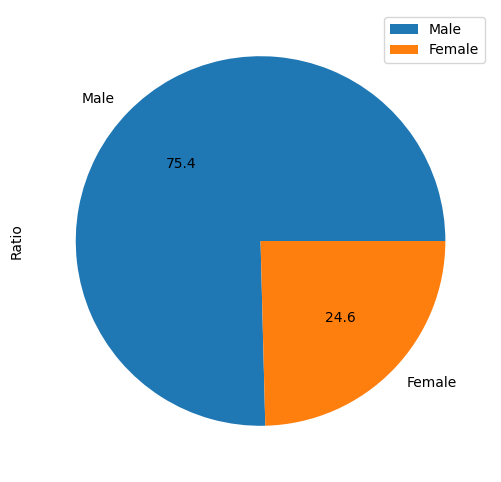

In [11]:
data = pd.DataFrame({'Ratio' : [len(df[df['Gender'] == 'M']), len(df[df['Gender'] == 'F'])]},
                    index = ['Male', 'Female'])

data.plot.pie(y = 'Ratio', figsize = (6,6), autopct = "%.1f")

<Axes: xlabel='Gender'>

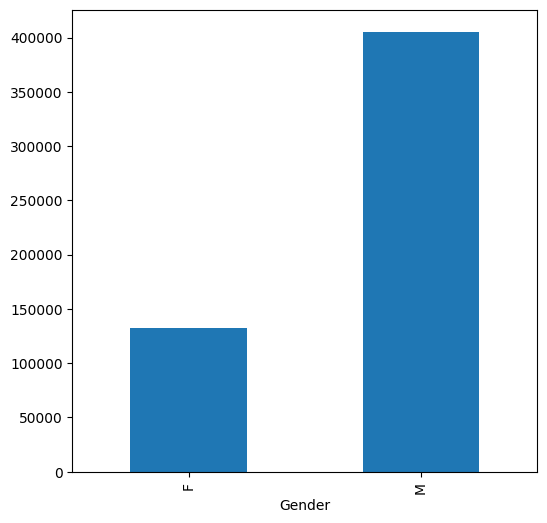

In [12]:
df.groupby('Gender').size().plot(kind = 'bar',
                                 figsize = (6,6))

In [13]:
df.groupby('Gender').size()

,0
Gender,
F,132197
M,405380


age

<Axes: title={'center': 'Purchase Distribution by Age'}, xlabel='Age'>

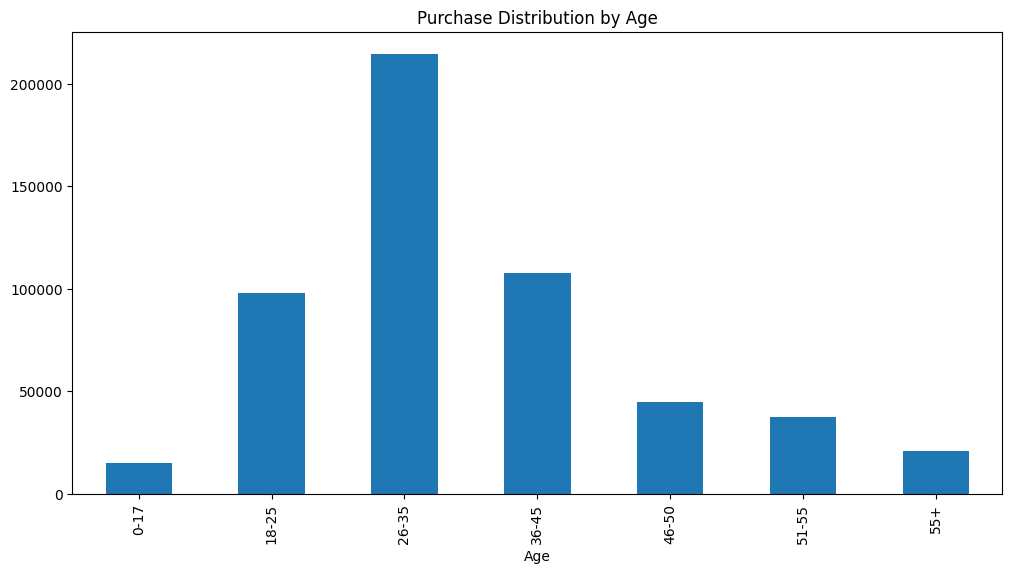

In [14]:
df.groupby('Age').size().plot(kind = 'bar', figsize = (12, 6), title = 'Purchase Distribution by Age')

In [15]:
data = df.groupby('Age')['Product_ID'].nunique().reset_index()

data.columns = ['Age','Products']

<Axes: xlabel='Age'>

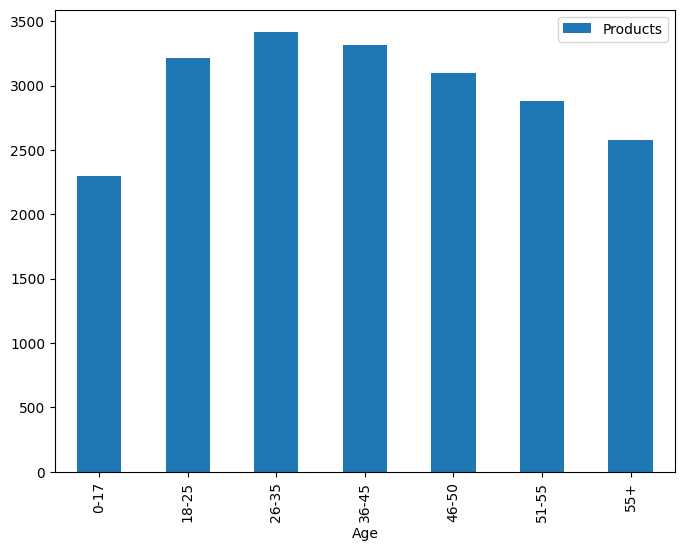

In [16]:
data.plot.bar(x = 'Age', figsize = (8,6))

<Axes: title={'center': 'Amount Spend by Age'}, xlabel='Age'>

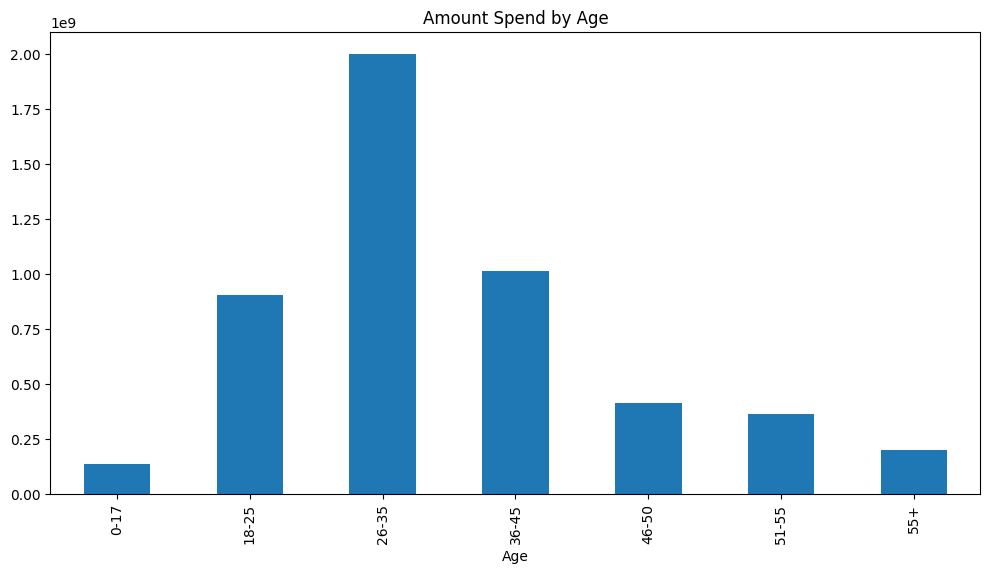

In [17]:
df.groupby('Age').sum()['Purchase'].plot(kind = 'bar', figsize = (12, 6), title = 'Amount Spend by Age')

<Axes: title={'center': 'Amount Spend by Age'}, xlabel='Age'>

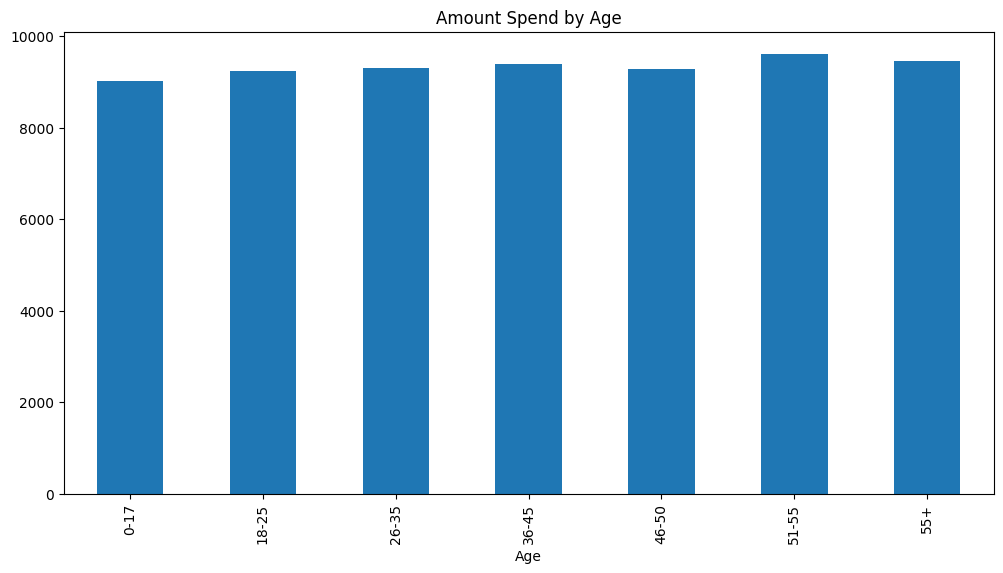

In [19]:
df.groupby('Age')['Purchase'].mean().plot(kind = 'bar', figsize = (12, 6), title = 'Amount Spend by Age')

<Axes: ylabel='Purchase'>

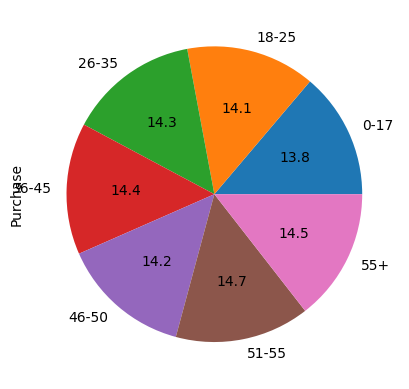

In [21]:
df.groupby('Age')['Purchase'].mean().plot(kind = 'pie', autopct = '%0.1f')

marital status

<Axes: >

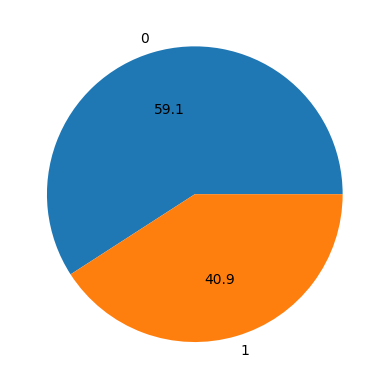

In [22]:
df.groupby('Marital_Status').size().plot(kind = 'pie', autopct = '%0.1f')


multiple column

<Axes: title={'center': 'Purchase Distribution by Age'}, xlabel='Age'>

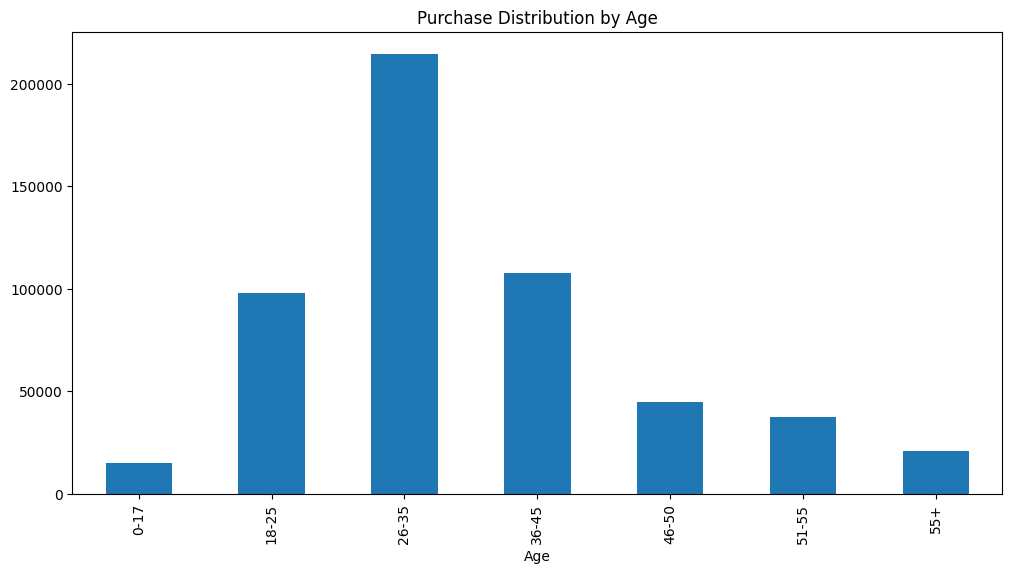

In [23]:
df.groupby('Age').size().plot(kind = 'bar', figsize = (12, 6), title = 'Purchase Distribution by Age')

<Axes: xlabel='Age', ylabel='count'>

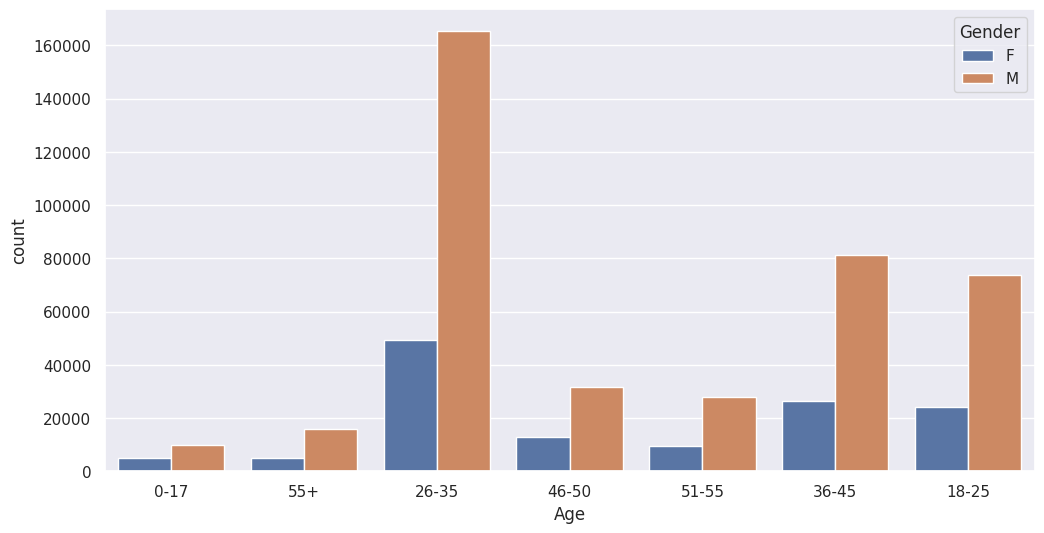

In [24]:
sns.set(rc = {'figure.figsize' : (12,6)})
sns.countplot(x = "Age", hue = 'Gender', data = df)

In [ ]:
sns.set(rc = {'figure.figsize' : (12,6)})
sns.countplot(x = "Gender", hue = 'Age', data = df)

In [ ]:
sns.set(rc = {'figure.figsize' : (6,6)})
sns.countplot(x = "Gender", hue = 'Marital_Status', data = df)

In [ ]:
sns.set(rc = {'figure.figsize' : (6,6)})
sns.countplot(x = "Marital_Status", hue = 'Gender', data = df)

In [ ]:
sns.countplot(x = df['City_Category'])

In [ ]:
sns.countplot(x = 'City_Category', hue = 'Age', data = df)

In [ ]:
sns.countplot(x = 'Age', hue = 'City_Category', data = df)

In [ ]:
sns.countplot(x = 'Marital_Status', hue = 'City_Category', data = df)

In [ ]:
df.groupby('City_Category').size().plot(kind = 'pie', autopct = '%0.1f')

In [ ]:
sns.countplot(x = 'City_Category', hue = 'Gender', data = df)

In [ ]:
df.groupby('City_Category').sum()['Purchase'].plot(kind = 'pie', autopct = "%0.1f")

In [ ]:
df.groupby('City_Category').mean()['Purchase'].plot(kind = 'pie', autopct = "%0.1f")

occupation and city

In [ ]:
sns.countplot(x = df['Stay_In_Current_City_Years'])

In [ ]:
sns.countplot(x = 'Stay_In_Current_City_Years', hue = 'Gender', data = df)

In [ ]:
sns.countplot(x = 'Stay_In_Current_City_Years', hue = 'Marital_Status', data = df)

In [ ]:
sns.countplot(x = 'Stay_In_Current_City_Years', hue = 'City_Category', data = df)

In [ ]:
sns.countplot(x = 'City_Category', hue = 'Age',data = df)

In [ ]:
df.groupby('Stay_In_Current_City_Years').sum()['Purchase'].plot(kind = 'bar')


In [ ]:
df.groupby('Stay_In_Current_City_Years').mean()['Purchase'].plot(kind = 'bar')

In [ ]:
sns.countplot(x = df['Occupation'])

In [ ]:
df.groupby('Occupation').size().sort_values().plot(kind = 'bar')

In [ ]:
df.groupby('Occupation').sum()['Purchase'].sort_values().plot(kind = 'bar')

In [ ]:
df.groupby('Occupation').mean()['Purchase'].sort_values().plot(kind = 'bar')

In [ ]:
sns.countplot(x = 'Occupation', hue = 'Marital_Status', data = df)


In [ ]:
sns.countplot(x = 'Occupation', hue = 'Gender', data = df)

In [ ]:
df.groupby('Occupation').nunique()['Product_ID'].plot(kind = 'bar')

In [ ]:
df.groupby('Product_Category_1').size().plot(kind = 'bar')

In [ ]:
df.groupby('Product_Category_1').size().sort_values().plot(kind = 'bar')

In [ ]:
df.groupby('Product_Category_1').sum()['Purchase'].sort_values().plot(kind = 'bar')

In [ ]:
df.groupby('Product_Category_1').mean()['Purchase'].sort_values().plot(kind = 'bar')

In [ ]:
df.groupby('Product_ID').sum()['Purchase'].nlargest(10).sort_values().plot(kind = 'bar')

In [ ]:
df.groupby('Product_ID').size().nlargest(10).sort_values().plot(kind = 'bar')

In [ ]:
sns.countplot(x = 'Product_Category_1', hue = 'Gender', data = df)

In [ ]:
sns.countplot(x = 'Product_Category_1', hue = 'Marital_Status', data = df)

In [ ]:
df['MaritalGender'] = (
    df['Gender'] + "_" + df['Marital_Status'].astype(str)
)

In [ ]:
df.head()

In [ ]:
sns.countplot(x = df['MaritalGender'])

In [ ]:
sns.countplot(x = df['Age'], hue = df['MaritalGender'])

In [ ]:
sns.countplot(x = df['Product_Category_1'], hue = df['MaritalGender'])

In [ ]:
sns.countplot(x = df['Stay_In_Current_City_Years'], hue = df['MaritalGender'])

In [ ]:
sns.countplot(x = df['City_Category'], hue = df['MaritalGender'])